# Retail Performance Analytics

# Business Analysis

This notebook builds on the work completed in the previous stages of the project.

After understanding the dataset and preparing it for analysis, the focus shifts to answering business questions using the cleaned data.

Each section explores one business question, presents the results and explains what they mean for the business.

## Project Roadmap

| Stage | Status |
|--------|--------|
| Business Understanding | ✅ Completed |
| Data Understanding | ✅ Completed |
| Data Cleaning | ✅ Completed |
| Business Analysis | 🟡 In Progress |
| SQL Analysis | ⏳ Planned |
| Power BI Dashboard | ⏳ Planned |
| Executive Report | ⏳ Planned |

## Notebook Objectives

This notebook aims to:

- Assess overall business performance.
- Identify the most valuable customers.
- Evaluate product performance.
- Compare sales across countries.
- Analyse sales trends over time.

## Analytical Approach

Instead of presenting a sequence of charts, this notebook is organised around business questions.

Each section answers one question using the cleaned dataset, followed by observations and business insights.

## Business Questions

This analysis seeks to answer the following business questions:

1. How is the business performing overall?
2. Who are the most valuable customers?
3. Which products drive revenue?
4. How does sales performance vary across countries?
5. How do sales evolve over time?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Pandas display options
pd.set_option("display.max_columns", None)

# Matplotlib default style
plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

#### Load Clean Dataset

In [14]:
clean_df = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    dtype={
        "InvoiceNo": str,
        "StockCode": str
    },
    parse_dates=["InvoiceDate"]
)

#### Observation

The cleaned dataset generated in the previous notebook is loaded from the **processed** folder.

InvoiceNo and StockCode are imported as text because they are business identifiers, while InvoiceDate is imported as a datetime column.

#### Dataset Overview

In [13]:
rows, columns = clean_df.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 525,460
Columns: 8


#### Observation

The cleaned dataset contains only valid retail sales transactions after applying the cleaning rules defined in the previous notebook.

It is now ready for the analyses presented in this notebook.

## Feature Engineering

The following variables are created to support the analyses presented in this notebook.

#### Line Total

The original dataset stores the quantity sold and the unit price separately.

The new variable combines both values and represents the total amount for each transaction line.

In [23]:
clean_df["LineTotal"] = (
    clean_df["Quantity"] *
    clean_df["UnitPrice"]
)

#### Validation

In [24]:
clean_df["LineTotal"].describe()

count    525460.000000
mean         20.252942
std         271.543898
min           0.000000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: LineTotal, dtype: float64

#### Observation

LineTotal represents the value of each transaction line and will be used in the analyses throughout this notebook.

### Year

The **Year** variable separates transactions by calendar year.

Although this dataset covers only two years, this variable makes it easier to organise the results by year.

In [17]:
clean_df["Year"] = (
    clean_df["InvoiceDate"]
    .dt.year
)

### Month

The **Month** variable stores the month as a number, making it easier to keep charts and tables in chronological order.

In [18]:
clean_df["Month"] = (
    clean_df["InvoiceDate"]
    .dt.month
)

### Month Name

The **MonthName** variable displays the month names, making tables and charts easier to read.

In [19]:
clean_df["MonthName"] = (
    clean_df["InvoiceDate"]
    .dt.month_name()
)

### Day of Week

The **DayOfWeek** variable is used to compare sales across the days of the week.

In [20]:
clean_df["DayOfWeek"] = (
    clean_df["InvoiceDate"]
    .dt.day_name()
)

### Hour

The **Hour** variable helps identify the busiest shopping hours.

In [21]:
clean_df["Hour"] = (
    clean_df["InvoiceDate"]
    .dt.hour
)

#### Validation

In [25]:
clean_df[
    [
        "InvoiceDate",
        "LineTotal",
        "Year",
        "Month",
        "MonthName",
        "DayOfWeek",
        "Hour"
    ]
].head()

,InvoiceDate,LineTotal,Year,Month,MonthName,DayOfWeek,Hour
0,2010-12-01 08:26:00,15.30,2010,12,December,Wednesday,8
1,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8
2,2010-12-01 08:26:00,22.00,2010,12,December,Wednesday,8
3,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8
4,2010-12-01 08:26:00,20.34,2010,12,December,Wednesday,8


#### Observation

The new variables are now available for the remaining analyses in this notebook.

# Business Question 1

## How is the business performing overall?

This section provides an overview of the business before exploring customers, products, countries and sales trends in more detail.

### Business KPIs

#### Total Sales

In [27]:
total_sales = clean_df["LineTotal"].sum()

print(f"Total Sales: £{total_sales:,.2f}")

Total Sales: £10,642,110.80


#### Observation

Total Sales represents the total value of all completed sales included in the analytical dataset.

---

#### Total Orders

In [26]:
total_orders = clean_df["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 20,134


#### Observation

Each invoice represents one completed order.

Counting unique invoice numbers provides the total number of orders analysed.

---

#### Average Order Value

Average Order Value represents the average amount spent per completed order.

In [36]:
invoice_total = (
    clean_df
    .groupby("InvoiceNo")["LineTotal"]
    .sum()
)

average_order_value = invoice_total.mean()

print(f"Average Order Value: £{average_order_value:,.2f}")

Average Order Value: £528.56


#### Observation

Average Order Value shows the average amount spent per completed order.

#### Total Customers

In [28]:
total_customers = clean_df["CustomerID"].nunique()

print(f"Identified Customers: {total_customers:,}")

Identified Customers: 4,339


#### Observation

This metric includes only customers with a valid customer identifier.

Anonymous purchases remain part of the sales analysis but are not included in customer-level metrics.

---

#### Unique Products

In [69]:
unique_products = clean_df["StockCode"].nunique()

print(f"Unique Products: {unique_products:,}")

Unique Products: 3,925


#### Observation

This metric shows how many different products were sold during the analysed period.

---

#### Countries

In [30]:
total_countries = clean_df["Country"].nunique()

print(f"Countries: {total_countries}")

Countries: 38


#### Observation

Sales were recorded across multiple countries.

Country-level performance will be explored later in the notebook.

### Business Insight

These KPIs provide an overall picture of the business.

The following sections examine customers, products, countries and sales trends to understand the results in more detail.

---

# Business Question 2

## Who are the most valuable customers?

This section identifies the customers who contribute most to total sales.

The analysis focuses on customer spending and purchase frequency to understand how revenue is distributed across the customer base.

### Customer Summary

In [62]:
customer_summary = (
    clean_df
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID")
    .agg(
        TotalSales=("LineTotal", "sum"),
        Orders=("InvoiceNo", "nunique"),
        ItemsPurchased=("Quantity", "sum")
    )
)

customer_summary["AverageOrderValue"] = (
    customer_summary["TotalSales"] /
    customer_summary["Orders"]
).round(2)

customer_summary = customer_summary.sort_values(
    by="TotalSales",
    ascending=False
)

customer_summary.head(10)

,TotalSales,Orders,ItemsPurchased,AverageOrderValue
CustomerID,,,,
14646.0,280206.02,74,197491,3786.57
18102.0,259657.30,60,64124,4327.62
17450.0,194390.79,46,69973,4225.89
16446.0,168472.50,2,80997,84236.25
14911.0,143711.17,201,80490,714.98
12415.0,124914.53,21,77670,5948.31
14156.0,117210.08,55,57768,2131.09
17511.0,91062.38,31,64549,2937.50
16029.0,80850.84,63,40108,1283.35


#### Observation

The customers with the highest sales are not necessarily those with the highest number of orders.

The table shows different purchasing patterns, with some customers generating high revenue through fewer but larger purchases.

### Business Insight

Customer value cannot be measured by purchase frequency alone.

Analysing sales together with the number of orders and the average order value provides a more complete view of customer purchasing behaviour.

---

# Business Question 3

## Which products drive revenue?

This section identifies the products that contribute most to total sales.

The analysis considers revenue, quantity sold and the number of orders for each product.

### Product Revenue

In [66]:
product_summary = (
    clean_df
    .groupby(
        ["StockCode", "Description"]
    )
    .agg(
        TotalSales=("LineTotal", "sum"),
        QuantitySold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values(
        by="TotalSales",
        ascending=False
    )
)

product_summary.head(10)

,,TotalSales,QuantitySold,Orders
StockCode,Description,,,
DOT,DOTCOM POSTAGE,206248.77,708,708
22423,REGENCY CAKESTAND 3 TIER,174156.54,13862,1989
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37584,2193
47566,PARTY BUNTING,99445.23,18287,1686
85099B,JUMBO BAG RED RETROSPOT,94159.81,48375,2092
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
POST,POSTAGE,78101.88,3150,1126
M,Manual,77750.27,6990,294


#### Investigation

The initial ranking includes entries such as **DOTCOM POSTAGE**, **POSTAGE** and **Manual**.

Although these records contribute to total revenue, they represent operational charges rather than physical products.

To answer the business question more accurately, a filtered version of the product summary is created for this analysis.

The original dataset and the original product summary remain unchanged.

In [71]:
product_summary_filtered = product_summary[
    ~product_summary.index.get_level_values("StockCode")
    .isin(["DOT", "POST", "M"])
]

product_summary_filtered.head(10)

,,TotalSales,QuantitySold,Orders
StockCode,Description,,,
22423,REGENCY CAKESTAND 3 TIER,174156.54,13862,1989
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37584,2193
47566,PARTY BUNTING,99445.23,18287,1686
85099B,JUMBO BAG RED RETROSPOT,94159.81,48375,2092
23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
23084,RABBIT NIGHT LIGHT,66870.03,30739,994
22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1160
84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1455


#### Observation

The ranking highlights the products that generated the highest sales during the analysed period.

The results show that products can reach similar sales levels through different purchasing patterns.

### Business Insight

Evaluating revenue together with quantity sold and order frequency provides a more complete picture of product performance.

This helps identify products that consistently contribute to sales as well as products that stand out because of large individual purchases.

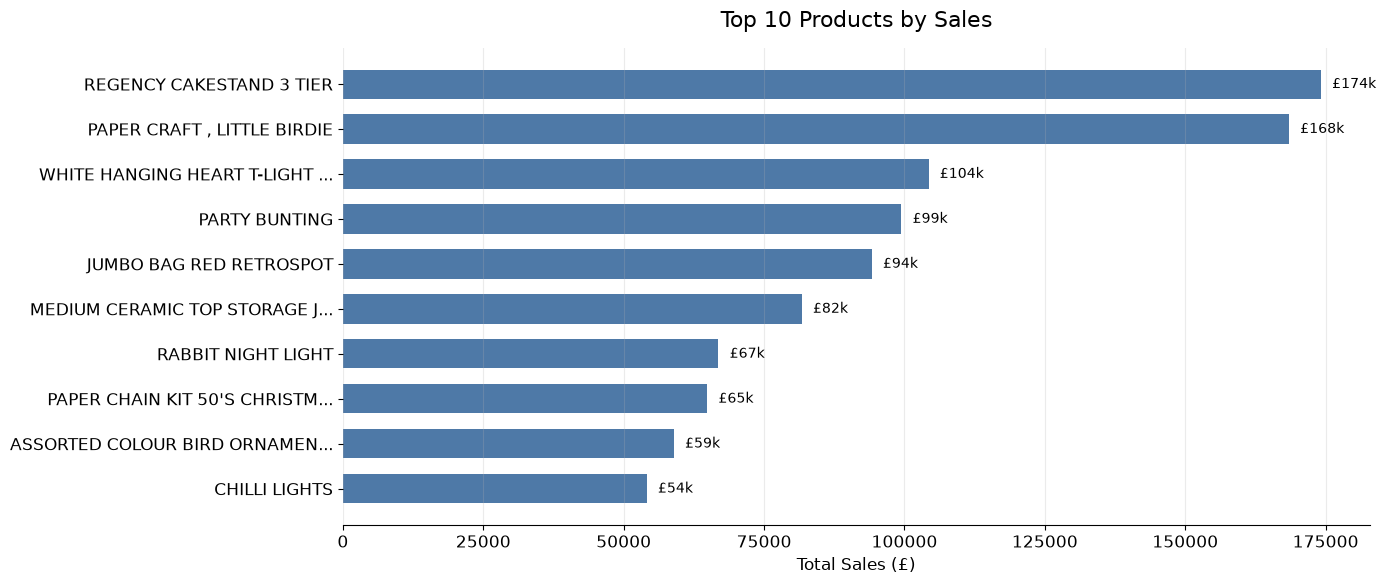

In [75]:
top_products = (
    product_summary_filtered
    .head(10)
    .sort_values("TotalSales")
    .copy()
)

labels = [
    text[:28] + "..."
    if len(text) > 28 else text
    for text in top_products.index.get_level_values("Description")
]

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    labels,
    top_products["TotalSales"],
    height=0.65,
    color="#4E79A7"
)

ax.set_title(
    "Top 10 Products by Sales",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Total Sales (£)")
ax.set_ylabel("")

ax.grid(axis="x", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for bar in bars:
    value = bar.get_width()
    ax.text(
        value + 2000,
        bar.get_y() + bar.get_height()/2,
        f"£{value/1000:.0f}k",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### Observation

The visual comparison highlights the products that contributed most to total sales.

The difference in sales between the leading products becomes easier to identify.

---

# Business Question 4

## How does sales performance vary across countries?

This section compares sales performance across countries.

The analysis examines revenue and order volume to understand the contribution of each market to the overall business.

### Country Summary

In [78]:
country_summary = (
    clean_df
    .groupby("Country")
    .agg(
        TotalSales=("LineTotal", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values(
        by="TotalSales",
        ascending=False
    )
)

country_summary.head(10)

,TotalSales,Orders,Customers
Country,,,
United Kingdom,9001744.094,18192,3921
Netherlands,285446.340,95,9
EIRE,283140.520,288,3
Germany,228678.400,457,94
France,209625.370,392,87
Australia,138453.810,57,9
Spain,61558.560,90,30
Switzerland,57067.600,54,21
Belgium,41196.340,98,25


#### Observation

The United Kingdom generated the highest sales by a wide margin.

The remaining countries contributed a much smaller share of total revenue.

### Business Insight

Most of the company's sales come from the United Kingdom.

Although the business operates in several countries, international sales account for a much smaller share of total revenue.

#### Investigation

The large difference between the United Kingdom and the remaining countries makes it difficult to compare international markets in a chart.

To improve the comparison, a second summary is created excluding the United Kingdom.

The original dataset and the original country summary remain unchanged..

In [81]:
country_summary_filtered = (
    country_summary
    .drop(index="United Kingdom")
)

country_summary_filtered.head(10)

,TotalSales,Orders,Customers
Country,,,
Netherlands,285446.34,95,9
EIRE,283140.52,288,3
Germany,228678.40,457,94
France,209625.37,392,87
Australia,138453.81,57,9
Spain,61558.56,90,30
Switzerland,57067.60,54,21
Belgium,41196.34,98,25
Sweden,38367.83,36,8


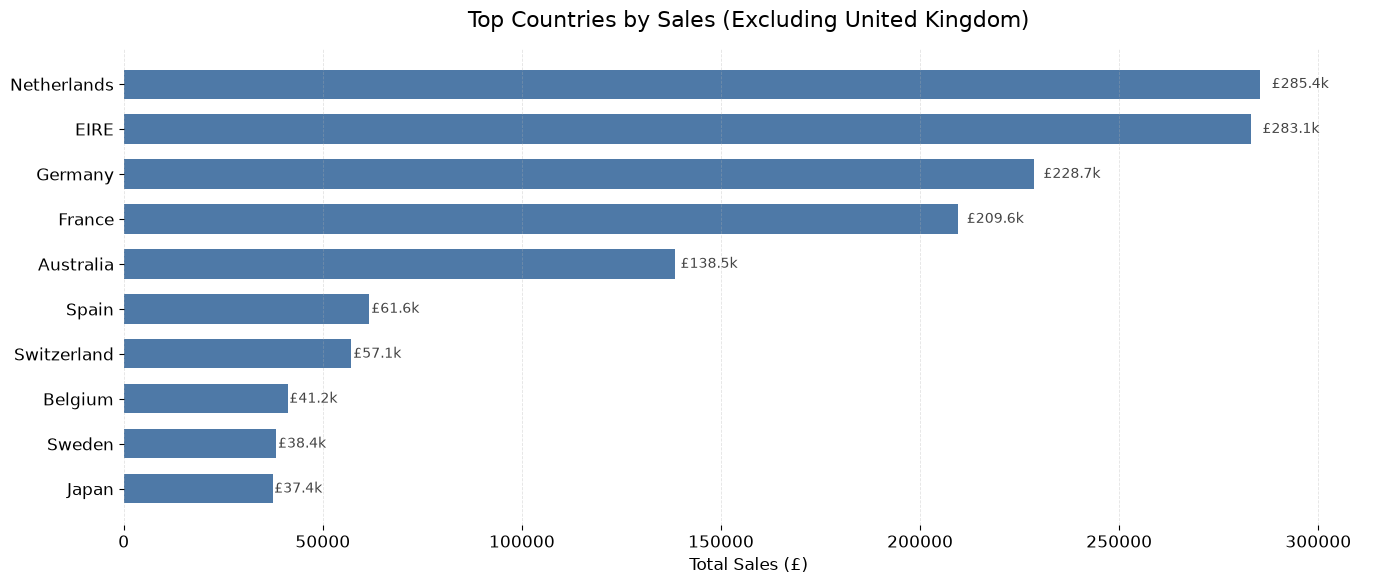

In [83]:
top_countries = (
    country_summary_filtered
    .head(10)
    .sort_values("TotalSales")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(
    top_countries.index,
    top_countries["TotalSales"],
    height=0.65,
    color="#4E79A7"
)

ax.set_title(
    "Top Countries by Sales (Excluding United Kingdom)",
    fontsize=16,
    pad=15
)

ax.set_xlabel("Total Sales (£)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

for bar in bars:
    value = bar.get_width()

    ax.text(
        value * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f"£{value/1000:.1f}k",
        va="center",
        fontsize=10,
        color="#444444"
    )

ax.set_xlim(
    0,
    top_countries["TotalSales"].max() * 1.10
)

plt.tight_layout()

plt.show()

#### Observation

Excluding the United Kingdom makes it easier to compare the contribution of the remaining countries.

The Netherlands, EIRE, Germany and France generated the highest sales among the international markets.

### Business Insight

Although sales are spread across several countries, only a small number of international markets account for most sales outside the United Kingdom.

Understanding the performance of these markets can help identify opportunities for future growth.

---

# Business Question 5

## How do sales evolve over time?

This section examines how sales changed over time during the analysed period.

Understanding sales patterns over time helps identify periods of stronger and weaker business performance.

### Monthly Sales

In [84]:
monthly_sales = (
    clean_df
    .groupby(
        clean_df["InvoiceDate"].dt.to_period("M")
    )
    .agg(
        TotalSales=("LineTotal", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
)

monthly_sales.index = (
    monthly_sales.index
    .astype(str)
)

monthly_sales

,TotalSales,Orders
InvoiceDate,,
2010-12,821452.730,1566
2011-01,689811.610,1089
2011-02,522545.560,1101
2011-03,716215.260,1459
2011-04,536968.491,1255
2011-05,769296.610,1689
2011-06,760547.010,1538
2011-07,718076.121,1485
2011-08,757841.380,1365


#### Investigation

Sales drop sharply in December 2011.

Before interpreting this as a decline in business performance, the last transaction date is checked to verify whether December contains a complete month of data.

In [85]:
clean_df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

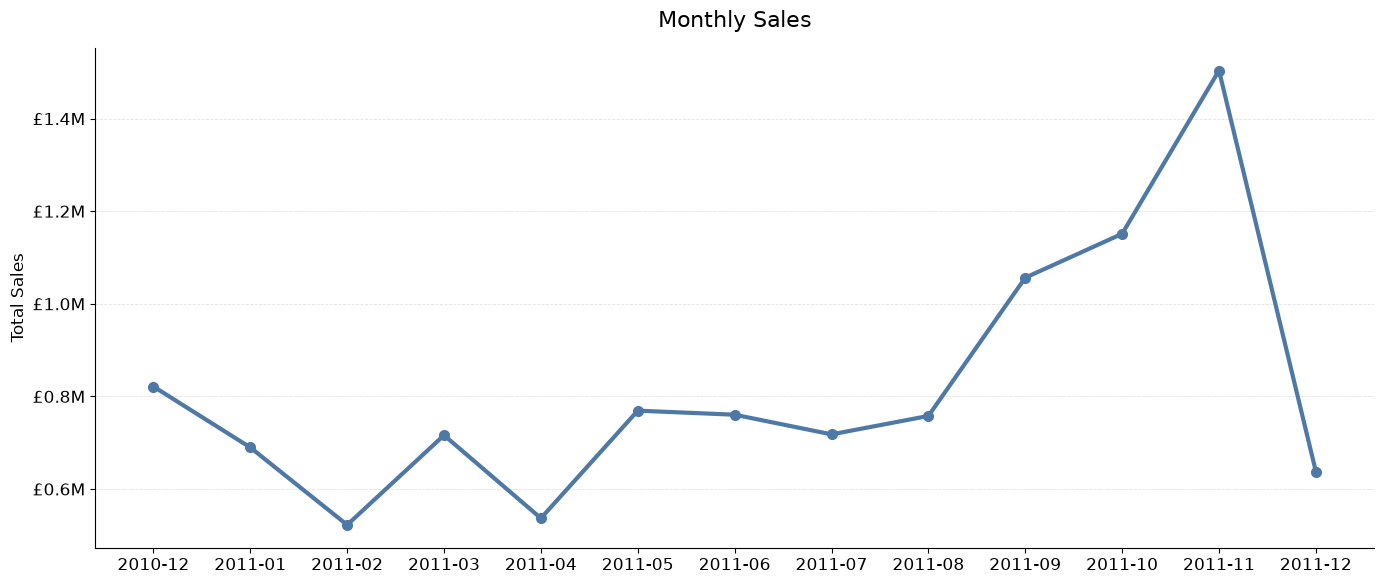

In [90]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    monthly_sales.index,
    monthly_sales["TotalSales"],
    color="#4E79A7",
    linewidth=3,
    marker="o",
    markersize=7
)

ax.set_title(
    "Monthly Sales",
    fontsize=16,
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Total Sales")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

#### Observation

Sales increased throughout most of 2011, reaching their highest level in November.

The lower sales recorded in December should be interpreted with caution because the dataset contains transactions only until **9 December 2011**, rather than the full month.

### Business Insight

The business showed steady sales growth during most of the analysed period, with particularly strong performance in the final quarter.

This section also highlights the importance of validating the completeness of time-based data before interpreting changes in business performance.

## Key Insights

The business analysis identified several important patterns across sales, customers, products, countries and time.

The main findings are summarised below.

- The business generated more than **£10.6 million** in sales across **20,134 completed orders**.

- Revenue is concentrated among a relatively small number of customers, although purchasing behaviour varies considerably between them.

- A limited number of products accounts for a large share of total sales, highlighting the importance of monitoring high-performing items.

- The United Kingdom is the company's primary market, while international sales are distributed across several smaller markets.

- Sales generally increased throughout 2011, reaching their highest level in November. The apparent decline in December reflects an incomplete month rather than a confirmed reduction in business performance.

## Business Recommendations

Based on the analyses presented in this notebook, the following opportunities could be considered by the business.

- Monitor high-value customers to improve customer retention and identify opportunities for personalised marketing.

- Prioritise inventory planning for products that consistently generate high sales.

- Explore opportunities to expand sales in international markets while maintaining the strong performance of the United Kingdom.

- Continue monitoring monthly sales to identify seasonal patterns using complete reporting periods.

- Complement this analysis with customer segmentation, profitability analysis and product category performance.

## Next Step

The next stage of this project focuses on SQL analysis.

Using the cleaned dataset created in the previous notebook, SQL queries will be used to answer additional business questions, validate key metrics and demonstrate data extraction and aggregation techniques commonly used in Business Intelligence projects.

This concludes the Business Analysis phase of the project.